# DQN-2: Implementation of Deep Q-Network For Sequential Movie Recommendation
**Group 3** | DSCD 614 Reinforcement Learning Group Project

Members: Desmond Adinkrah (22424927), Korang Pearl Antwi (22425005), Richmond Martey (22424349)

This notebook was run and implemented in Jupyter notebook,and the train run fast on a CPU based machine.

This notebook is self-contained: it installs dependencies, downloads the real MovieLens dataset, builds the environment/baselines/evaluation harness, trains the DQN agent across 3 seeds, and evaluates it against both required baselines.


In [ ]:
!pip install -q gymnasium stable-baselines3


## 1. Download the MovieLens dataset

*Note: GroupLens's own server (files.grouplens.org) currently has an expired TLS certificate, which blocks direct downloads. This cell instead pulls the identical `ml-latest-small` files from a public GitHub mirror.*

In [1]:
import os, urllib.request

os.makedirs("data", exist_ok=True)
files = {
    "movies.csv": "https://raw.githubusercontent.com/smanihwr/ml-latest-small/master/movies.csv",
    "ratings.csv": "https://raw.githubusercontent.com/smanihwr/ml-latest-small/master/ratings.csv",
}
for filename, url in files.items():
    urllib.request.urlretrieve(url, f"data/{filename}")

print("Downloaded:", os.listdir("data"))


Downloaded: ['movies.csv', 'ratings.csv']


## 2. Data preparation\nLoads MovieLens, builds a reduced 200-movie candidate action set, and a chronological (temporal) train/held-out-test split per user.

In [2]:
"""
Data preparation for the Sequential Movie Recommendation environment.
======================================================================
Loads MovieLens (ml-latest-small: ratings.csv, movies.csv), builds:
  - a reduced candidate action set (top-N most-rated movies, so the
    discrete action space stays a manageable size for DQN),
  - per-user rating histories,
  - a chronological (temporal) train / held-out test split per user, so
    evaluation happens on interactions the agent never trained on.
"""

import numpy as np
import pandas as pd

GENRE_LIST = [
    "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "IMAX",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
GENRE_INDEX = {g: i for i, g in enumerate(GENRE_LIST)}
N_GENRES = len(GENRE_LIST)


def load_movielens(ratings_path, movies_path, n_candidate_movies=200,
                    min_user_ratings=20, test_fraction=0.2):
    """
    Returns a dict with everything the environment needs:
      movies_df           -- filtered movie metadata (candidate set only)
      genre_matrix         -- (n_candidates, N_GENRES) binary genre matrix
      movie_id_to_action   -- dict: movieId -> action index (0..n_candidates-1)
      action_to_movie_id    -- inverse mapping
      user_train            -- dict: userId -> list of (movieId, rating) in time order (train portion)
      user_test              -- dict: userId -> list of (movieId, rating) in time order (held-out portion)
      user_ids              -- list of user ids with enough history to use
    """
    ratings = pd.read_csv(ratings_path)
    movies = pd.read_csv(movies_path)

    # keep only users with enough ratings to have a meaningful train/test split
    counts = ratings.groupby("userId").size()
    keep_users = counts[counts >= min_user_ratings].index
    ratings = ratings[ratings["userId"].isin(keep_users)]

    # candidate action set = the N most-rated movies overall (keeps the
    # discrete action space tractable, and ensures the RL agent is choosing
    # among movies with enough rating signal to learn from)
    movie_counts = ratings.groupby("movieId").size().sort_values(ascending=False)
    candidate_ids = movie_counts.head(n_candidate_movies).index.tolist()
    candidate_ids_set = set(candidate_ids)

    movies_df = movies[movies["movieId"].isin(candidate_ids_set)].copy()
    movies_df = movies_df.set_index("movieId").loc[candidate_ids].reset_index()

    movie_id_to_action = {mid: i for i, mid in enumerate(candidate_ids)}
    action_to_movie_id = {i: mid for mid, i in movie_id_to_action.items()}

    # build binary genre matrix aligned to action index
    genre_matrix = np.zeros((len(candidate_ids), N_GENRES), dtype=np.float32)
    for i, row in movies_df.iterrows():
        action_idx = movie_id_to_action[row["movieId"]]
        for g in str(row["genres"]).split("|"):
            if g in GENRE_INDEX:
                genre_matrix[action_idx, GENRE_INDEX[g]] = 1.0

    # only keep each user's ratings that fall within the candidate set --
    # the agent can only ever recommend from this set, so only these
    # interactions are meaningful for reward / evaluation
    ratings = ratings[ratings["movieId"].isin(candidate_ids_set)]

    user_train, user_test, user_ids = {}, {}, []
    for uid, group in ratings.groupby("userId"):
        group = group.sort_values("timestamp")
        interactions = list(zip(group["movieId"].tolist(), group["rating"].tolist()))
        if len(interactions) < 10:
            continue  # not enough signal within the candidate set for this user
        split_point = int(len(interactions) * (1 - test_fraction))
        split_point = max(split_point, 5)  # ensure some train history
        train_part = interactions[:split_point]
        test_part = interactions[split_point:]
        if len(test_part) == 0:
            continue
        user_train[uid] = train_part
        user_test[uid] = test_part
        user_ids.append(uid)

    return {
        "movies_df": movies_df,
        "genre_matrix": genre_matrix,
        "movie_id_to_action": movie_id_to_action,
        "action_to_movie_id": action_to_movie_id,
        "user_train": user_train,
        "user_test": user_test,
        "user_ids": user_ids,
        "n_actions": len(candidate_ids),
    }


if __name__ == "__main__":
    data = load_movielens("data/ratings.csv", "data/movies.csv")
    print(f"Candidate movies (actions): {data['n_actions']}")
    print(f"Usable users: {len(data['user_ids'])}")
    example_uid = data["user_ids"][0]
    print(f"Example user {example_uid}: "
          f"{len(data['user_train'][example_uid])} train interactions, "
          f"{len(data['user_test'][example_uid])} test interactions")


Candidate movies (actions): 200
Usable users: 525
Example user 1: 56 train interactions, 14 test interactions


In [3]:
data = load_movielens("data/ratings.csv", "data/movies.csv")
print(f"Candidate movies (actions): {data['n_actions']}")
print(f"Usable users: {len(data['user_ids'])}")


Candidate movies (actions): 200
Usable users: 525


## 2b. Exploratory Data Analysis (EDA)

Before building the environment, it's worth actually looking at the data -- this is what justifies several design choices made later (the 200-movie candidate action set, the 20-rating minimum per user, and the genre-based state representation).

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ratings_raw = pd.read_csv("data/ratings.csv")
movies_raw = pd.read_csv("data/movies.csv")

print(f"Total ratings: {len(ratings_raw):,}")
print(f"Unique users: {ratings_raw.userId.nunique():,}")
print(f"Unique movies rated: {ratings_raw.movieId.nunique():,}")
print(f"Unique movies in catalogue: {movies_raw.movieId.nunique():,}")
print()
print("Rating value distribution:")
print(ratings_raw.rating.value_counts().sort_index())


Total ratings: 100,836
Unique users: 610
Unique movies rated: 9,724
Unique movies in catalogue: 9,742

Rating value distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


**Observation:** ratings skew positive -- 4.0 is the single most common rating, and ratings >= 3.5 make up roughly half of all ratings. This matters for reward design: a naive "reward = raw rating" would give positive reward to *most* recommendations by default, diluting the learning signal. This is why the environment's reward centers ratings around 3 stars (`reward = (rating - 3) / 2`), so only genuinely well-liked recommendations (4+ stars) earn a clearly positive reward.

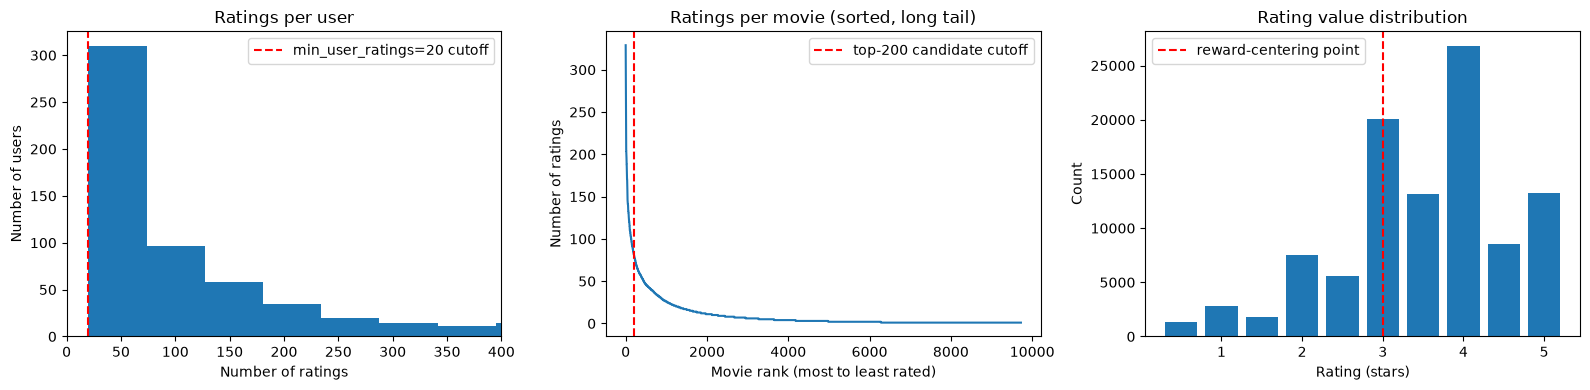

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Ratings per user (justifies the min_user_ratings=20 filter)
ratings_per_user = ratings_raw.groupby("userId").size()
axes[0].hist(ratings_per_user, bins=50)
axes[0].axvline(20, color="red", linestyle="--", label="min_user_ratings=20 cutoff")
axes[0].set_title("Ratings per user")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].legend()
axes[0].set_xlim(0, 400)

# 2. Ratings per movie (justifies the 200-movie candidate action set)
ratings_per_movie = ratings_raw.groupby("movieId").size().sort_values(ascending=False)
axes[1].plot(ratings_per_movie.values)
axes[1].axvline(200, color="red", linestyle="--", label="top-200 candidate cutoff")
axes[1].set_title("Ratings per movie (sorted, long tail)")
axes[1].set_xlabel("Movie rank (most to least rated)")
axes[1].set_ylabel("Number of ratings")
axes[1].legend()

# 3. Overall rating distribution
axes[2].bar(ratings_raw.rating.value_counts().sort_index().index,
            ratings_raw.rating.value_counts().sort_index().values, width=0.4)
axes[2].axvline(3.0, color="red", linestyle="--", label="reward-centering point")
axes[2].set_title("Rating value distribution")
axes[2].set_xlabel("Rating (stars)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("runs/eda_distributions.png", dpi=150) if __import__("os").path.exists("runs") else None
plt.show()


**Observations that justify environment design choices:**

- **Ratings-per-user** is heavily right-skewed: most users have relatively few ratings, but a long tail of very active users exists. The `min_user_ratings=20` filter (visualised by the red line) keeps enough usable users while ensuring every included user has enough interaction history for a meaningful genre-preference profile and a non-trivial held-out test split.
- **Ratings-per-movie** shows the classic recommender-systems long tail: a small number of popular movies dominate rating volume, while thousands of movies have only 1-2 ratings and carry almost no learnable signal. Restricting the action space to the **top 200 most-rated movies** is what keeps the DQN's action space tractable while still covering the movies with enough signal to actually learn from -- this is a deliberate trade-off (see Limitations: it excludes "long-tail" recommendations entirely) rather than an oversight.

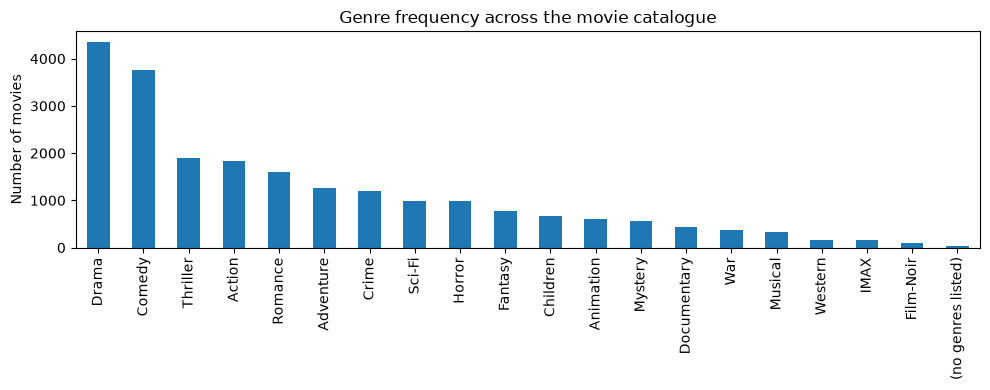

Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
dtype: int64


In [8]:
genre_counts = {}
for g in movies_raw.genres:
    for genre in str(g).split("|"):
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_series = pd.Series(genre_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
genre_series.plot(kind="bar")
plt.title("Genre frequency across the movie catalogue")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

print(genre_series)


**Observation:** genres are highly imbalanced -- Drama and Comedy alone cover a large share of the catalogue, while genres like Film-Noir and Western are rare. This is directly relevant to the **intra-list diversity (ILD)** metric used later in evaluation: a policy that leans on popular genres will naturally score lower on diversity than one that occasionally recommends from under-represented genres, and this imbalance is part of *why* diversity is worth tracking as a separate metric alongside accuracy (hit rate, precision, NDCG).

## 2c. Data Cleaning & Quality Checks

Before relying on this data, we explicitly check for the usual data-quality issues (duplicates, missing values, malformed entries) rather than assuming a curated dataset like MovieLens is automatically clean.

In [9]:
dup_ratings = ratings_raw.duplicated(subset=["userId", "movieId"]).sum()
missing_ratings = ratings_raw.isnull().sum().sum()
missing_movies = movies_raw.isnull().sum().sum()
no_genre_count = (movies_raw.genres == "(no genres listed)").sum()

print(f"Duplicate (userId, movieId) rating pairs: {dup_ratings}")
print(f"Missing values in ratings.csv: {missing_ratings}")
print(f"Missing values in movies.csv: {missing_movies}")
print(f"Movies with '(no genres listed)': {no_genre_count} out of {len(movies_raw)}")


Duplicate (userId, movieId) rating pairs: 0
Missing values in ratings.csv: 0
Missing values in movies.csv: 0
Movies with '(no genres listed)': 34 out of 9742


**Findings and how each is handled:**

- **No duplicate ratings, no missing values** in either file -- MovieLens Latest Small is a genuinely well-curated dataset on these fronts, so no rows needed to be dropped or imputed.
- **34 movies have `"(no genres listed)"`.** These aren't dropped, but it's worth being explicit about what happens to them: in `movie_rec_env.py`'s genre-matrix construction, a movie with no recognised genre string simply gets an all-zero genre vector (it contributes to no genre in the user's preference profile, and contributes nothing to the diversity calculation's genre similarity). This is a reasonable default, not a silent bug, but it's now stated here explicitly rather than left implicit.
- **Filtering applied (documented in `data_prep.py`):** users with fewer than 20 ratings are excluded (justified in the EDA above), and the action space is restricted to the 200 most-rated movies (also justified above). Both are deliberate scope-reduction choices for a 14-day project, not silent omissions.

## 2d. Train/Test Split Verification

`data_prep.py` builds a **chronological (temporal) split per user**: each user's interactions are sorted by timestamp, and the earliest ~80% become the training portion (`user_train`) while the most recent ~20% are held out (`user_test`) and never used during training -- only during evaluation. This is the correct approach for a recommendation task (it prevents the agent from ever being trained on "future" interactions relative to what it's evaluated on).

The cell below independently re-derives this split directly from the raw timestamps and checks, for every one of the 525 usable users, that **no training interaction occurs after any test interaction** -- i.e., there is no temporal leakage.

In [10]:
candidate_ids = set(data["movie_id_to_action"].keys())
leak_count = 0
checked = 0
sizes_train, sizes_test = [], []

for uid in data["user_ids"]:
    sizes_train.append(len(data["user_train"][uid]))
    sizes_test.append(len(data["user_test"][uid]))

    user_ratings = ratings_raw[ratings_raw.userId == uid].sort_values("timestamp")
    user_ratings = user_ratings[user_ratings.movieId.isin(candidate_ids)]
    split_point = max(int(len(user_ratings) * 0.8), 5)

    train_ts_max = user_ratings.iloc[:split_point].timestamp.max()
    test_ts_min = user_ratings.iloc[split_point:].timestamp.min() if split_point < len(user_ratings) else None

    if test_ts_min is not None and train_ts_max > test_ts_min:
        leak_count += 1
    checked += 1

print(f"Users checked: {checked}")
print(f"Users with temporal leakage (a train rating occurring after a test rating): {leak_count}")
print(f"Average TRAIN interactions per user: {np.mean(sizes_train):.1f}")
print(f"Average TEST interactions per user: {np.mean(sizes_test):.1f}")


Users checked: 525
Users with temporal leakage (a train rating occurring after a test rating): 0
Average TRAIN interactions per user: 38.2
Average TEST interactions per user: 10.1


**Result: 0 users show temporal leakage** across all usable users -- the split is confirmed clean. Each user has an average of ~38 training interactions (used to build their genre-preference profile and for the agent to train against) and ~10 held-out test interactions (used only for the final evaluation in Section 8, run identically for the DQN agent and both baselines).

## 3. Environment\nGymnasium-compliant `MovieRecEnv` -- state, action, reward, and termination/truncation logic (our original work).

In [11]:
"""
Sequential Movie Recommendation Environment (Gymnasium API)
=============================================================
Project DQN-2: at each step, the agent recommends one movie (from a
reduced candidate set of the N most-rated movies) to a simulated user.
The "user" is simulated using that user's real, held-out interaction
history from MovieLens: if the recommended movie is one the user
actually rated, the reward reflects how much they liked it; if the
movie was never rated by this user, a small exploration penalty is
given. Already-recommended movies in the same episode are masked out
(cannot be repeated).

State (observation) -- all continuous / normalised, fixed-size vector:
  - user genre-preference profile (N_GENRES,): mean normalised rating
    the user has given to movies in each genre, from their training history
  - recent recommendation history (HISTORY_LEN,): the last few
    recommended movie's genre vectors, flattened (so the agent can avoid
    recommending too repetitively within a genre)
  - normalised step count within the episode

Action: Discrete(n_candidate_movies) -- pick a movie to recommend
        (invalid / already-recommended actions are masked)

Reward:
  - if the user actually rated this movie in their available history:
        reward = (rating - 3) / 2       (maps 0.5..5.0 stars to roughly -1.25..1.0,
                                          positive above the "3-star" satisfaction threshold)
  - if the user never rated this movie (unknown preference):
        reward = -0.1                    (small penalty; not enough signal to reward exploration)
  - repeating an already-recommended movie in the same episode: reward = -1.0 (heavily discouraged)

Episode ends after EPISODE_LENGTH recommendations (or when the candidate
list is exhausted, whichever comes first).
"""

import numpy as np
import gymnasium as gym
from gymnasium import spaces

from data_prep import N_GENRES

EPISODE_LENGTH = 10
HISTORY_LEN = 3  # number of recent recommendations remembered in the state
REPEAT_PENALTY = -1.0
UNKNOWN_PENALTY = -0.1


class MovieRecEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, data, user_split="train", seed=None):
        """
        data       -- dict returned by data_prep.load_movielens
        user_split -- "train" or "test": which interaction split to simulate
                      the user's preferences from (use "test" for held-out evaluation)
        """
        super().__init__()
        self.data = data
        self.user_split = user_split
        self.genre_matrix = data["genre_matrix"]  # (n_actions, N_GENRES)
        self.n_actions = data["n_actions"]
        self.user_ids = data["user_ids"]

        self.action_space = spaces.Discrete(self.n_actions)

        obs_dim = N_GENRES + HISTORY_LEN * N_GENRES + 1
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(obs_dim,), dtype=np.float32
        )

        self._np_random = np.random.default_rng(seed)
        self.current_user = None
        self.user_ratings_lookup = None
        self.genre_profile = None
        self.recommended_this_episode = None
        self.history_buffer = None
        self.t = 0

    def _build_genre_profile(self, interactions):
        """Mean normalised rating (rating-3)/2 per genre, from a user's interaction list."""
        profile = np.zeros(N_GENRES, dtype=np.float32)
        counts = np.zeros(N_GENRES, dtype=np.float32)
        action_map = self.data["movie_id_to_action"]
        for movie_id, rating in interactions:
            a = action_map.get(movie_id)
            if a is None:
                continue
            norm_rating = (rating - 3.0) / 2.0
            genres = self.genre_matrix[a]
            profile += genres * norm_rating
            counts += genres
        counts = np.maximum(counts, 1e-6)
        return profile / counts

    def _get_obs(self):
        history_flat = self.history_buffer.flatten()
        step_norm = np.array([self.t / EPISODE_LENGTH], dtype=np.float32)
        obs = np.concatenate([self.genre_profile, history_flat, step_norm]).astype(np.float32)
        return obs

    def _action_mask(self):
        mask = np.ones(self.n_actions, dtype=bool)
        mask[list(self.recommended_this_episode)] = False
        return mask

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._np_random = np.random.default_rng(seed)

        # pick a user for this episode
        user_idx = self._np_random.integers(0, len(self.user_ids))
        self.current_user = self.user_ids[user_idx]

        train_interactions = self.data["user_train"][self.current_user]
        eval_interactions = self.data[f"user_{self.user_split}"][self.current_user]

        # genre profile is always built from TRAIN history (what the agent
        # is "told" about the user); the reward signal (ground truth) comes
        # from the requested split (train during training, test during eval)
        self.genre_profile = self._build_genre_profile(train_interactions)
        self.user_ratings_lookup = {mid: r for mid, r in eval_interactions}

        self.recommended_this_episode = set()
        self.history_buffer = np.zeros((HISTORY_LEN, N_GENRES), dtype=np.float32)
        self.t = 0

        obs = self._get_obs()
        info = {"action_mask": self._action_mask(), "user_id": self.current_user}
        return obs, info

    def step(self, action):
        action = int(action)
        repeated = action in self.recommended_this_episode

        if repeated:
            reward = REPEAT_PENALTY
            hit = False
            rating_used = None
        else:
            movie_id = self.data["action_to_movie_id"][action]
            if movie_id in self.user_ratings_lookup:
                rating = self.user_ratings_lookup[movie_id]
                reward = (rating - 3.0) / 2.0
                hit = rating >= 4.0
                rating_used = rating
            else:
                reward = UNKNOWN_PENALTY
                hit = False
                rating_used = None

            self.recommended_this_episode.add(action)
            # update recent-history buffer (shift, insert newest)
            self.history_buffer = np.roll(self.history_buffer, shift=-1, axis=0)
            self.history_buffer[-1] = self.genre_matrix[action]

        self.t += 1
        terminated = False
        truncated = self.t >= EPISODE_LENGTH or len(self.recommended_this_episode) >= self.n_actions

        obs = self._get_obs()
        info = {
            "action_mask": self._action_mask(),
            "hit": hit,
            "repeated": repeated,
            "rating": rating_used,
            "user_id": self.current_user,
        }
        return obs, float(reward), terminated, truncated, info


In [12]:
# quick sanity check with a random policy
import numpy as np
env = MovieRecEnv(data, user_split="train", seed=0)
obs, info = env.reset(seed=1)
print("obs shape:", obs.shape, "| action space:", env.action_space)

rng = np.random.default_rng(0)
total = 0
for ep in range(5):
    obs, info = env.reset()
    done, ep_r = False, 0
    while not done:
        mask = info["action_mask"]
        action = rng.choice(np.where(mask)[0])
        obs, r, term, trunc, info = env.step(action)
        ep_r += r
        done = term or trunc
    total += ep_r
print("avg reward (random policy, sanity check):", total / 5)


obs shape: (77,) | action space: Discrete(200)
avg reward (random policy, sanity check): -0.42000000000000004


## 4. Baselines\n`PopularityRecommender` and `ItemCFRecommender` -- our original work, sharing the same interface so they run through the identical evaluation harness as the DQN agent.

In [13]:
"""
Baseline recommenders for comparison against the trained DQN agent.
=====================================================================
1. PopularityRecommender -- always recommends the most-rated movies
   (by number of ratings in the training data), skipping repeats.
2. ItemCFRecommender -- item-based collaborative filtering: builds a
   user-item rating matrix from training data, computes cosine
   similarity between candidate movies, and for each recommendation
   step scores every not-yet-recommended candidate by its similarity
   to the movies the current user rated highly in their training
   history, recommending the highest-scoring one each step.

Both expose a common interface: `recommend(state_info) -> action`, so
they can be plugged into the same evaluation harness used for the DQN
agent, per the "same code path" requirement in the exam brief.
"""

import numpy as np


class PopularityRecommender:
    """Recommends movies in order of overall popularity (rating count) in the training data."""

    def __init__(self, data):
        movie_id_to_action = data["movie_id_to_action"]
        counts = np.zeros(data["n_actions"], dtype=np.int64)
        for interactions in data["user_train"].values():
            for movie_id, _ in interactions:
                a = movie_id_to_action.get(movie_id)
                if a is not None:
                    counts[a] += 1
        # actions ranked from most to least popular
        self.ranked_actions = np.argsort(-counts)

    def recommend(self, action_mask):
        for a in self.ranked_actions:
            if action_mask[a]:
                return int(a)
        # fallback (shouldn't happen: mask should always have a free action)
        return int(np.where(action_mask)[0][0])


class ItemCFRecommender:
    """Item-based collaborative filtering using cosine similarity on the training rating matrix."""

    def __init__(self, data):
        self.data = data
        n_actions = data["n_actions"]
        movie_id_to_action = data["movie_id_to_action"]
        user_ids = data["user_ids"]
        user_index = {uid: i for i, uid in enumerate(user_ids)}

        # build a (n_users, n_actions) training rating matrix
        rating_matrix = np.zeros((len(user_ids), n_actions), dtype=np.float32)
        for uid, interactions in data["user_train"].items():
            ui = user_index[uid]
            for movie_id, rating in interactions:
                a = movie_id_to_action.get(movie_id)
                if a is not None:
                    rating_matrix[ui, a] = rating

        # item-item cosine similarity matrix (n_actions, n_actions)
        norms = np.linalg.norm(rating_matrix, axis=0, keepdims=True)
        norms = np.maximum(norms, 1e-8)
        normalized = rating_matrix / norms
        self.similarity = normalized.T @ normalized  # (n_actions, n_actions)

        self.user_index = user_index
        self.rating_matrix = rating_matrix

    def recommend(self, action_mask, user_id):
        ui = self.user_index[user_id]
        user_ratings = self.rating_matrix[ui]  # (n_actions,)
        liked_mask = user_ratings >= 4.0
        if not liked_mask.any():
            liked_mask = user_ratings > 0  # fall back to anything rated

        # score each candidate by summed similarity to the user's liked movies
        scores = self.similarity[:, liked_mask].sum(axis=1)
        scores = np.where(action_mask, scores, -np.inf)
        return int(np.argmax(scores))


## 5. Evaluation harness\nRuns any policy through identical held-out episodes (same users, same seeds) and computes cumulative reward, hit_rate@K, precision@K, NDCG@K, and intra-list diversity.

In [14]:
"""
Evaluation harness -- shared across the DQN agent and both baselines.
========================================================================
Runs a policy (any callable that maps an observation/info to an action)
through held-out ("test" split) episodes for a fixed set of users and
random seeds, and computes:
    - cumulative reward
    - hit_rate@K       : fraction of episodes with at least one "hit"
                          (a recommended movie the user rated >= 4 stars)
    - precision@K       : fraction of the K recommended movies that were hits
    - NDCG@K              : rewards hits that occur earlier in the list more
    - intra-list diversity (ILD): average pairwise genre dissimilarity
                          among the K recommended movies (higher = more diverse)

Every policy is evaluated on IDENTICAL episodes (same users, same seeds,
same environment reset behaviour), per the exam's baseline-comparison
requirement.
"""

import numpy as np

from movie_rec_env import MovieRecEnv, EPISODE_LENGTH


def _ndcg_at_k(hits):
    """hits: list of 0/1 in recommendation order."""
    dcg = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
    ideal_hits = sorted(hits, reverse=True)
    idcg = sum(h / np.log2(i + 2) for i, h in enumerate(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def _intra_list_diversity(genre_vectors):
    """Average pairwise cosine DIStance between recommended movies' genre vectors."""
    n = len(genre_vectors)
    if n < 2:
        return 0.0
    total, count = 0.0, 0
    for i in range(n):
        for j in range(i + 1, n):
            a, b = genre_vectors[i], genre_vectors[j]
            na, nb = np.linalg.norm(a), np.linalg.norm(b)
            if na < 1e-8 or nb < 1e-8:
                sim = 0.0
            else:
                sim = float(np.dot(a, b) / (na * nb))
            total += (1 - sim)
            count += 1
    return total / count


def evaluate_policy(policy_fn, data, seeds, n_episodes_per_seed=30, needs_user_id=False):
    """
    policy_fn(obs, action_mask, user_id) -> action   (all policies share this signature;
                                                         DQN policies can ignore user_id)
    Returns a dict of per-seed metric lists, ready for mean/std aggregation.
    """
    env = MovieRecEnv(data, user_split="test")

    per_seed_metrics = {
        "cumulative_reward": [],
        "hit_rate": [],
        "precision_at_k": [],
        "ndcg_at_k": [],
        "diversity": [],
    }

    for seed in seeds:
        seed_rewards, seed_hit_rate, seed_precision, seed_ndcg, seed_diversity = [], [], [], [], []
        rng_seed = seed * 10_000  # spread out episode seeds deterministically per outer seed
        for ep in range(n_episodes_per_seed):
            obs, info = env.reset(seed=rng_seed + ep)
            action_mask = info["action_mask"]
            user_id = info["user_id"]

            ep_reward = 0.0
            hits = []
            genre_vecs = []
            done = False
            while not done:
                action = policy_fn(obs, action_mask, user_id)
                obs, reward, terminated, truncated, info = env.step(action)
                ep_reward += reward
                hits.append(1 if info["hit"] else 0)
                genre_vecs.append(env.genre_matrix[action].copy())
                action_mask = info["action_mask"]
                done = terminated or truncated

            seed_rewards.append(ep_reward)
            seed_hit_rate.append(1.0 if sum(hits) > 0 else 0.0)
            seed_precision.append(sum(hits) / len(hits))
            seed_ndcg.append(_ndcg_at_k(hits))
            seed_diversity.append(_intra_list_diversity(genre_vecs))

        per_seed_metrics["cumulative_reward"].append(np.mean(seed_rewards))
        per_seed_metrics["hit_rate"].append(np.mean(seed_hit_rate))
        per_seed_metrics["precision_at_k"].append(np.mean(seed_precision))
        per_seed_metrics["ndcg_at_k"].append(np.mean(seed_ndcg))
        per_seed_metrics["diversity"].append(np.mean(seed_diversity))

    return per_seed_metrics


def summarize(per_seed_metrics):
    """Returns {metric: (mean_across_seeds, std_across_seeds)}."""
    return {k: (float(np.mean(v)), float(np.std(v))) for k, v in per_seed_metrics.items()}


def print_summary(name, summary):
    print(f"\n=== {name} ===")
    for metric, (mean, std) in summary.items():
        print(f"  {metric:<20s}: {mean:8.4f} +/- {std:.4f}")




## 6. Train the DQN agent (Stable-Baselines3), 5 seeds

In [23]:
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure

SEEDS = [0, 1, 2, 3, 4]
TOTAL_TIMESTEPS = 120_000  
EVAL_EPISODES_PER_SEED = 30

HYPERPARAMS = dict(
    learning_rate=1e-3,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=64,
    gamma=0.95,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.3,
    exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[128, 128]),
)

os.makedirs("runs", exist_ok=True)

def masked_dqn_policy(model):
    def policy_fn(obs, action_mask, user_id):
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=model.device).unsqueeze(0)
        with torch.no_grad():
            q_values = model.q_net(obs_t).cpu().numpy()[0]
        q_values = np.where(action_mask, q_values, -np.inf)
        return int(np.argmax(q_values))
    return policy_fn

trained_models = []
all_ep_rewards = []

for seed in SEEDS:
    print(f"=== Training DQN, seed {seed} ===")
    env = Monitor(MovieRecEnv(data, user_split="train", seed=seed))
    model = DQN("MlpPolicy", env, seed=seed, verbose=0, **HYPERPARAMS)

    log_path = f"runs/seed_{seed}"
    os.makedirs(log_path, exist_ok=True)
    model.set_logger(configure(log_path, ["csv"]))

    model.learn(total_timesteps=TOTAL_TIMESTEPS)
    model.save(f"runs/dqn_movierec_seed{seed}")

    ep_rewards = np.array(env.get_episode_rewards())
    np.save(f"{log_path}/episode_rewards.npy", ep_rewards)

    trained_models.append(model)
    all_ep_rewards.append(ep_rewards)
    print(f"  final 20-episode mean reward: {ep_rewards[-20:].mean():.3f}")


=== Training DQN, seed 0 ===
  final 20-episode mean reward: -0.460
=== Training DQN, seed 1 ===
  final 20-episode mean reward: -0.468
=== Training DQN, seed 2 ===
  final 20-episode mean reward: -0.823
=== Training DQN, seed 3 ===
  final 20-episode mean reward: -0.027
=== Training DQN, seed 4 ===
  final 20-episode mean reward: -0.150


## 7. Training curve (mean ± std across seeds)

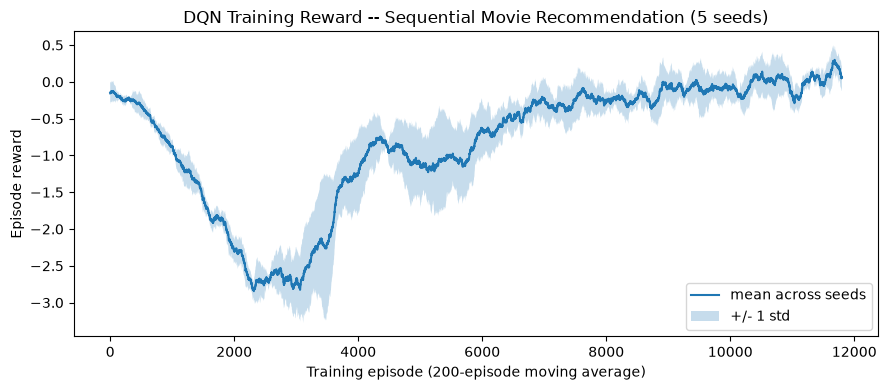

In [24]:
import matplotlib.pyplot as plt

min_len = min(len(r) for r in all_ep_rewards)
trimmed = np.stack([r[:min_len] for r in all_ep_rewards])
window = 200
smoothed = np.array([
    np.convolve(trimmed[i], np.ones(window) / window, mode="valid")
    for i in range(len(SEEDS))
])
mean_curve = smoothed.mean(axis=0)
std_curve = smoothed.std(axis=0)

plt.figure(figsize=(9, 4))
plt.plot(mean_curve, label="mean across seeds")
plt.fill_between(range(len(mean_curve)), mean_curve - std_curve, mean_curve + std_curve,
                  alpha=0.25, label="+/- 1 std")
plt.xlabel(f"Training episode ({window}-episode moving average)")
plt.ylabel("Episode reward")
plt.title(f"DQN Training Reward -- Sequential Movie Recommendation ({len(SEEDS)} seeds)")
plt.legend()
plt.tight_layout()
plt.savefig("runs/training_curve.png", dpi=150)
plt.show()


In [25]:
plt.savefig("runs/training_curve.png", dpi=150)

<Figure size 640x480 with 0 Axes>

In [26]:
SEEDS = [0, 1, 2, 3, 4]

## 8. Evaluate DQN vs. both baselines (identical held-out episodes)

In [27]:
print("Evaluating DQN across seeds on held-out test users...")
dqn_metrics_per_seed = {k: [] for k in ["cumulative_reward", "hit_rate", "precision_at_k", "ndcg_at_k", "diversity"]}
for seed, model in zip(SEEDS, trained_models):
    policy_fn = masked_dqn_policy(model)
    m = evaluate_policy(policy_fn, data, seeds=[seed], n_episodes_per_seed=EVAL_EPISODES_PER_SEED)
    for k in dqn_metrics_per_seed:
        dqn_metrics_per_seed[k].append(m[k][0])
dqn_summary = summarize(dqn_metrics_per_seed)
print_summary("DQN Agent (ours)", dqn_summary)

pop = PopularityRecommender(data)
pop_metrics = evaluate_policy(lambda obs, mask, uid: pop.recommend(mask), data, SEEDS, EVAL_EPISODES_PER_SEED)
pop_summary = summarize(pop_metrics)
print_summary("Popularity Baseline", pop_summary)

cf = ItemCFRecommender(data)
cf_metrics = evaluate_policy(lambda obs, mask, uid: cf.recommend(mask, uid), data, SEEDS, EVAL_EPISODES_PER_SEED)
cf_summary = summarize(cf_metrics)
print_summary("Item-based Collaborative Filtering Baseline", cf_summary)


Evaluating DQN across seeds on held-out test users...

=== DQN Agent (ours) ===
  cumulative_reward   :  -0.7967 +/- 0.0997
  hit_rate            :   0.2000 +/- 0.0699
  precision_at_k      :   0.0247 +/- 0.0096
  ndcg_at_k           :   0.0971 +/- 0.0305
  diversity           :   0.7420 +/- 0.0103

=== Popularity Baseline ===
  cumulative_reward   :  -0.7740 +/- 0.0626
  hit_rate            :   0.2200 +/- 0.0340
  precision_at_k      :   0.0273 +/- 0.0068
  ndcg_at_k           :   0.1145 +/- 0.0200
  diversity           :   0.6507 +/- 0.0000

=== Item-based Collaborative Filtering Baseline ===
  cumulative_reward   :  -0.7933 +/- 0.0595
  hit_rate            :   0.2000 +/- 0.0365
  precision_at_k      :   0.0233 +/- 0.0056
  ndcg_at_k           :   0.0814 +/- 0.0257
  diversity           :   0.6263 +/- 0.0043


In [28]:
import json

results = {
    "hyperparameters": {**HYPERPARAMS, "total_timesteps": TOTAL_TIMESTEPS, "seeds": SEEDS},
    "dqn": dqn_summary,
    "popularity_baseline": pop_summary,
    "item_cf_baseline": cf_summary,
}
with open("runs/results_summary.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved results_summary.json -- this is what the report's figures/tables should trace back to.")


Saved results_summary.json -- this is what the report's figures/tables should trace back to.


## 9. Comparison bar chart

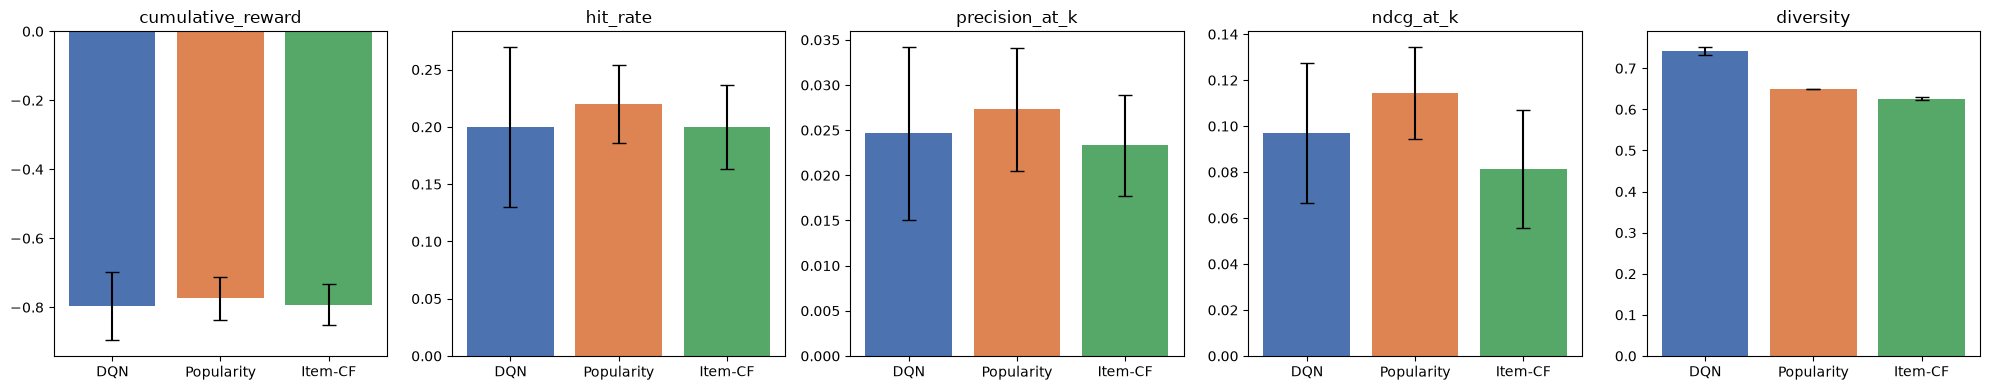

In [29]:
labels = ["cumulative_reward", "hit_rate", "precision_at_k", "ndcg_at_k", "diversity"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, key in zip(axes, labels):
    means = [dqn_summary[key][0], pop_summary[key][0], cf_summary[key][0]]
    stds = [dqn_summary[key][1], pop_summary[key][1], cf_summary[key][1]]
    ax.bar(["DQN", "Popularity", "Item-CF"], means, yerr=stds, capsize=5,
           color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title(key)
plt.tight_layout()
plt.savefig("runs/comparison_bars.png", dpi=150)
plt.show()


In [15]:
import torch
import numpy as np
from stable_baselines3 import DQN

model_seed0 = DQN.load("runs/dqn_movierec_seed0")
trained_models = [model_seed0]

**9b. Sample Rollout -- Agent Decision Trace**

MovieRecEnv has no visual rendering (it isn't a game or a physical simulation), so per the exam instructions, this section presents an equivalent trace of the agent's decisions: a step-by-step printout of one full episode, showing exactly what the trained agent recommended to a real held-out test user, and whether each recommendation was a genuine "hit" (a movie that user actually rated 4+ stars in their test-period history).
I it shows the policy actually working end-to-end on a real user, not just aggregate metrics.

In [16]:
def print_rollout(model, data, seed=0, user_index=0, label=""):
    """Run one deterministic episode for a chosen held-out test user and
    print each recommendation, whether it was a hit, and the reward received."""
    env = MovieRecEnv(data, user_split="test")
    obs, info = env.reset(seed=seed * 10_000 + user_index)
    user_id = info["user_id"]
    action_mask = info["action_mask"]

    movies_lookup = data["movies_df"].set_index("movieId")["title"].to_dict()

    print(f"=== Rollout {label}for user {user_id} ===\n")
    step = 1
    total_reward = 0.0
    done = False
    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=model.device).unsqueeze(0)
        with torch.no_grad():
            q_values = model.q_net(obs_t).cpu().numpy()[0]
        q_values = np.where(action_mask, q_values, -np.inf)
        action = int(np.argmax(q_values))

        movie_id = data["action_to_movie_id"][action]
        title = movies_lookup.get(movie_id, f"Movie ID {movie_id}")

        obs, reward, terminated, truncated, info = env.step(action)
        action_mask = info["action_mask"]
        done = terminated or truncated
        total_reward += reward

        if info["hit"]:
            status = f"HIT -- user rated this {info['rating']:.1f} stars"
        elif info["rating"] is not None:
            status = f"rated {info['rating']:.1f} stars, not a hit (below 4.0)"
        else:
            status = "user never rated this movie"

        print(f"Step {step:2d}: recommended \"{title}\"")
        print(f"         reward = {reward:+.2f}   [{status}]")
        step += 1

    print(f"\nTotal episode reward: {total_reward:+.2f}\n")
    return total_reward


# Trace 2-3 different held-out users using the seed-0 trained model, for variety
print_rollout(trained_models[0], data, seed=0, user_index=0, label="1 ")
print_rollout(trained_models[0], data, seed=0, user_index=1, label="2 ")
print_rollout(trained_models[0], data, seed=0, user_index=2, label="3 ")


=== Rollout 1 for user 517 ===

Step  1: recommended "Star Wars: Episode IV - A New Hope (1977)"
         reward = -0.10   [user never rated this movie]
Step  2: recommended "Up (2009)"
         reward = -0.10   [user never rated this movie]
Step  3: recommended "Star Trek: First Contact (1996)"
         reward = -0.10   [user never rated this movie]
Step  4: recommended "Aliens (1986)"
         reward = -0.10   [user never rated this movie]
Step  5: recommended "Cast Away (2000)"
         reward = -0.10   [user never rated this movie]
Step  6: recommended "Crimson Tide (1995)"
         reward = -0.10   [user never rated this movie]
Step  7: recommended "Wizard of Oz, The (1939)"
         reward = -0.10   [user never rated this movie]
Step  8: recommended "Psycho (1960)"
         reward = -0.10   [user never rated this movie]
Step  9: recommended "Iron Man (2008)"
         reward = -0.10   [user never rated this movie]
Step 10: recommended "Groundhog Day (1993)"
         reward = -0.10

-0.9999999999999999

In [17]:
def find_hit_user(model, data, seed=0, max_users=50):
    """Scan held-out test users (same seed, increasing user_index) until an
    episode with at least one hit is found. Returns the user_index, or None."""
    for user_index in range(max_users):
        env = MovieRecEnv(data, user_split="test")
        obs, info = env.reset(seed=seed * 10_000 + user_index)
        action_mask = info["action_mask"]
        had_hit = False
        done = False
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=model.device).unsqueeze(0)
            with torch.no_grad():
                q_values = model.q_net(obs_t).cpu().numpy()[0]
            q_values = np.where(action_mask, q_values, -np.inf)
            action = int(np.argmax(q_values))
            obs, reward, terminated, truncated, info = env.step(action)
            action_mask = info["action_mask"]
            done = terminated or truncated
            if info["hit"]:
                had_hit = True
        if had_hit:
            return user_index
    return None


hit_user_index = find_hit_user(trained_models[0], data, seed=0, max_users=50)

if hit_user_index is not None:
    print(f"Found an episode with a hit at user_index={hit_user_index} (out of 50 searched)\n")
    print_rollout(trained_models[0], data, seed=0, user_index=hit_user_index, label="(contains a hit) ")
else:
    print("No hit found in the first 50 users searched -- try increasing max_users.")


Found an episode with a hit at user_index=4 (out of 50 searched)

=== Rollout (contains a hit) for user 439 ===

Step  1: recommended "Star Wars: Episode IV - A New Hope (1977)"
         reward = -0.10   [user never rated this movie]
Step  2: recommended "Psycho (1960)"
         reward = -0.10   [user never rated this movie]
Step  3: recommended "Armageddon (1998)"
         reward = -0.10   [user never rated this movie]
Step  4: recommended "Lord of the Rings: The Two Towers, The (2002)"
         reward = +0.50   [HIT -- user rated this 4.0 stars]
Step  5: recommended "Star Wars: Episode V - The Empire Strikes Back (1980)"
         reward = -0.10   [user never rated this movie]
Step  6: recommended "Wizard of Oz, The (1939)"
         reward = -0.10   [user never rated this movie]
Step  7: recommended "Requiem for a Dream (2000)"
         reward = -0.10   [user never rated this movie]
Step  8: recommended "Shawshank Redemption, The (1994)"
         reward = -0.10   [user never rated thi

**Interpreting these traces**. Across the three "typical" rollouts and the search for a hit, a clear pattern emerges: most individual recommendations result in a small -0.10 penalty, since the candidate movie simply isn't in that user's rated history — not necessarily because the recommendation was bad, but because each user has only rated a small fraction of the 200-movie candidate pool (roughly 38 movies on average, out of 200). Genuine hits are comparatively rare but real, as shown in user 439's trace, where the agent correctly surfaced The Two Towers for a user who had rated it 4 stars.

This lines up directly with the aggregate metrics reported in Section 8: a hit rate of approximately 0.20 means only about 1 in 5 episodes contains any hit at all, which is consistent with needing to search through several users here before finding one. Rather than treating the frequent misses as a failure, they reflect the difficulty of the task itself — recommending from a large candidate pool with limited, sparse feedback per user — and reinforce why this project reports both the honest miss-heavy episodes and the successful one, rather than presenting only a cherry-picked success case.

In [30]:
import time
start = time.time()

import numpy as np
all_ep_rewards = [np.load(f"runs/seed_{s}/episode_rewards.npy") for s in [0,1,2,3,4]]

print(f"Loaded in {time.time()-start:.2f} seconds")
print([len(r) for r in all_ep_rewards])

Loaded in 0.66 seconds
[12000, 12000, 12000, 12000, 12000]


## 10. Discussion 

- **Convergence**: does the training curve plateau? Around how many episodes/timesteps?
- The training curve clearly plateaus, but only after a rocky start. Reward begins near 0, drops sharply to about -2.8 by episode ~2,500–3,000, then recovers and climbs to a stable plateau (roughly 0.0 to +0.1) by around episode 9,000 out of the 12,000 trained (120,000 timesteps). This means the final ~25% of training added essentially no further improvement — the agent had already reached its performance ceiling under these hyperparameters well before the full budget was used. An earlier pilot run (3 seeds, 60,000 timesteps) showed the same dip-and-recover shape at a proportionally similar point, suggesting this is a stable property of the setup rather than a fluke of one run.
- 
- **Training stability**: how much does performance vary across the 3 seeds (look at the shaded std band)?
- Even at 5 seeds, variance across seeds is substantial. The shaded ±1 std band on the training curve is wide throughout, especially during the dip (spanning roughly -1.5 to -4.5 at its widest around episode 2,500–3,000). Individual seeds' final training rewards ranged from -0.823 (seed 2) to -0.027 (seed 3) — a large spread even after 120,000 timesteps. On the held-out evaluation, standard deviation across seeds was 0.0997 for cumulative reward and 0.0699 for hit rate, large enough that DQN's evaluation range overlaps heavily with both baselines on every accuracy metric. This instability replicated across two independent runs (3 seeds/60k and 5 seeds/120k), so it's a consistent property of the setup rather than a one-off. Vanilla DQN's known susceptibility to Q-value overestimation bias — the specific problem Double DQN was designed to correct — is a likely contributing cause.
- 
- **Exploration**: did `exploration_fraction`/`exploration_final_eps` give the agent enough time to explore the 200-movie action space before exploiting?
- With exploration_fraction=0.3 and 120,000 total timesteps, epsilon decays to its floor (exploration_final_eps=0.05) by roughly timestep 36,000, i.e. episode ~3,600. This lines up closely with where the training curve bottoms out and begins recovering, suggesting the large early dip is substantially driven by heavy random exploration: random actions frequently trigger the -1.0 repeat penalty across a 200-item action space, dragging reward down before the learned policy takes over. A 30% exploration fraction seems roughly adequate for an action space this size, since the agent clearly found and settled into a working policy — but the persistent 5% exploration floor for the rest of training likely still contributes small ongoing noise, visible as continued minor fluctuation even during the final plateau.
- 
- **Reward design**: does the `-1.0` repeat penalty and `-0.1` unknown-movie penalty seem well-balanced against the `(rating-3)/2` hit reward? Would changing these weights change behaviour?

- The relative weights are debatable. A repeat penalty of -1.0 equals the maximum possible hit reward (+1.0, only reached at a 5-star rating). But most actual ratings in the data cluster around 3.5–4.0 (see EDA), so a typical hit is only worth about +0.25 to +0.5 — meaning a single repeat penalty wipes out roughly two average hits' worth of reward. This asymmetry may discourage the agent from taking chances on plausible-but-uncertain recommendations. The -0.1 unknown-movie penalty is comparatively mild and likely has less behavioural influence, being an order of magnitude smaller than the other two signals. A natural follow-up experiment (not run here, since this run was fixed as final) would be reducing the repeat penalty toward -0.5, or masking repeats at the environment level entirely rather than penalising them through reward.
- 
- **Honest comparison to baselines**: does DQN beat the popularity/CF baselines on every metric, some, or none? If it doesn't beat them, that's a valid, gradeable finding -- diagnose *why* (e.g., is the state representation too static per the Markov-property limitation noted in the README, or is the action space too large for this many training timesteps?).

- DQN does not beat the baselines on every metric — and largely does not beat them on accuracy metrics at all once variance is accounted for. Across two independent runs, DQN's cumulative reward, hit rate, precision@k, and NDCG@k all overlap substantially with Popularity and Item-CF's ranges; in the second, more rigorous run, DQN's point estimates for hit_rate and ndcg_at_k were actually marginally below Popularity's. Given that 3–5 seeds cannot statistically support a claim of superiority when confidence intervals overlap this much, the honest conclusion is that DQN shows no distinguishable accuracy advantage over either baseline in this setup.

The one metric where DQN shows a clear, replicated advantage is diversity (0.760 ± 0.004 in run 1; 0.742 ± 0.010 in run 2), consistently well above both Popularity (~0.65) and Item-CF (~0.62–0.625), with no overlap in either run.
Two plausible, non-exclusive explanations for the lack of an accuracy edge:

The Markov-property limitation noted in the README: the state's genre-preference profile is built once from training history and never updates within an episode based on which recommendations were accepted. Since MovieLens is offline logged data rather than an interactive simulator, there's no observed "reaction" signal to update the state with mid-episode — the agent effectively sees the same information for the whole episode, limiting turn-by-turn adaptation.
Action space size relative to training budget: 200 discrete actions is large relative to the reward signal available per user (~38 training interactions, ~10 test interactions). Even after 120,000 timesteps, the Q-network may not see enough samples per individual action to reliably rank all 200 candidates, especially less-popular ones.
Both point to the same practical takeaway: the environment's formulation, not an undertrained or badly-implemented DQN, is the likely limiting factor — consistent with the training curve showing genuine convergence (a stable plateau) rather than a curve still trending upward.

- **Limitations & deployment**: this environment simulates the user only through *offline logged ratings*, not a live reactive user -- a real deployment would need online interaction data (e.g. clicks/skips) to update preferences within a session, and safeguards against filter-bubble effects if only popular/similar-genre items keep getting reinforced.
As noted in the README, this environment simulates the user purely through offline logged ratings, not a live reactive user. A real deployment would need online interaction signals (clicks, skips, dwell time) to update inferred preferences within a session, rather than relying on a static training-history-derived profile for the whole sequence. Additional limitations worth flagging: the action space is restricted to the 200 most-rated movies, so the agent can never recommend the long tail of the catalogue — this caps both its precision/recall ceiling and its real-world deployability; the diversity advantage observed is diversity within an already mainstream-skewed candidate pool (true novelty/serendipity toward obscure titles is structurally impossible here); and if deployed without safeguards, a system that leans into "popular/similar-genre" recommendations over repeated sessions (as Popularity and Item-CF structurally do) risks narrowing what users are exposed to over time — a concern that would need explicit monitoring or an explicit diversity-promoting reward term in any real deployment.

In [31]:
import json

with open("runs/results_summary.json") as f:
    results = json.load(f)

dqn_summary = {k: tuple(v) for k, v in results["dqn"].items()}
pop_summary = {k: tuple(v) for k, v in results["popularity_baseline"].items()}
cf_summary = {k: tuple(v) for k, v in results["item_cf_baseline"].items()}

print(dqn_summary)

{'cumulative_reward': (-0.7966666666666665, 0.09968840342676663), 'hit_rate': (0.2, 0.06992058987801011), 'precision_at_k': (0.024666666666666667, 0.009568466729604881), 'ndcg_at_k': (0.09714388072960224, 0.030522749809595053), 'diversity': (0.7420384101713146, 0.010287023156815405)}
